In [12]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[0]
sys.path.append(str(ROOT_DIR))


In [13]:
import os
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
import numpy as np
import json
import pandas as pd

from src.models.model import PeakPredictorLSTM
from src.data.pmodel_generation import (
    generate_multiple_series,
)


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)


def recall_vs_anticipation(
    predictions,
    true_peaks,
    lookahead,
    threshold,
    burn_in=100,
):
    """
    Computes recall as a function of minimum anticipation time,
    discarding early points without valid prediction context.

    Returns:
        ks: minimum anticipation (in time steps)
        recalls: fraction of peaks anticipated at least k steps ahead
    """

    # Positions of real peaks
    peak_positions = np.where(true_peaks == 1)[0]

    # Discard peaks too close to the beginning (no valid anticipation window)
    peak_positions = peak_positions[
        peak_positions >= burn_in + lookahead
    ]

    ks = np.arange(1, lookahead + 1)
    recalls = []

    if len(peak_positions) == 0:
        return ks, np.zeros_like(ks, dtype=float)

    for k in ks:
        detected = 0

        for t_peak in peak_positions:
            t_start = t_peak - lookahead

            window = predictions[t_start:t_peak]

            # Ignore windows with NaNs (extra safety)
            if np.isnan(window).any():
                continue

            alarm_idx = np.where(window >= threshold)[0]

            if len(alarm_idx) > 0:
                t_alarm = t_start + alarm_idx[0]
                if (t_peak - t_alarm) >= k:
                    detected += 1

        recalls.append(detected / len(peak_positions))

    return ks, np.array(recalls)

def build_anticipatory_labels(peaks, lookahead):
    """
    peaks: array binário (0/1) indicando pico instantâneo
    lookahead: horizonte de previsão

    Retorna:
    y_future[t] = 1 se existir pico em [t+1, t+lookahead]
    """
    y_future = np.zeros_like(peaks)

    for t in range(len(peaks)):
        end = min(t + lookahead + 1, len(peaks))
        if np.any(peaks[t + 1 : end]):
            y_future[t] = 1

    return y_future



def evaluate_and_plot_streaming(
    model,
    df,
    device,
    lookahead,
    threshold=0.6,
    plot=True,
    box_cut=None,
    title="P-model time series",
):
    """
    Evaluates a single time series in a streaming (causal) regime.
    """

    # Select appropriate signal column
    signal_col = (
        "normalized_amplitude"
        if "normalized_amplitude" in df.columns
        else "normalized"
    )

    series = df[signal_col].values
    true_peaks = df["peak"].values.astype(int)
    instant_peaks = df["peak"].values.astype(int)
    true_peaks_classic_metrics = build_anticipatory_labels(instant_peaks, lookahead)


    model.eval()
    hidden = model.init_hidden()
    predictions = []

    with torch.no_grad():
        for value in series:
            x_t = torch.tensor([[[value]]], dtype=torch.float32).to(device)
            y_hat, hidden = model.step(x_t, hidden)
            predictions.append(y_hat.item())

    predictions = np.array(predictions)

    # Apply sigmoid if the model outputs logits
    predictions = 1 / (1 + np.exp(-predictions))

    # Temporal adjustment (anticipatory prediction)
    predictions[:lookahead] = np.nan
    valid = ~np.isnan(predictions)

    y_true = true_peaks_classic_metrics[valid]
    y_score = predictions[valid]
    y_pred = (y_score >= threshold).astype(int)

    metrics = {
        # "AUC-ROC": roc_auc_score(y_true, y_score)
        # if len(np.unique(y_true)) > 1
        # else np.nan,
        "AUC-PR": average_precision_score(y_true, y_score)
        if len(np.unique(y_true)) > 1
        else np.nan,
        # "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "P-value": df["p_value"].iloc[0] if "p_value" in df.columns else np.nan
    }

    if plot:
        # Recall vs Anticipation Plot
        x_ini, x_fim = box_cut
        thresholds = [threshold, 0.7, 0.8, 0.9]

        colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
        linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))] 
        markers = ["o", "x", "^", "D"]

        plt.figure(figsize=(6, 4))

        ks = None
        recalls = None

        for th, c, ls, m in zip(thresholds, colors, linestyles, markers):
            ks_sub, recalls_sub = recall_vs_anticipation(
                predictions,
                true_peaks,
                lookahead,
                threshold=th,
            )

            if th == threshold:
                ks = ks_sub
                recalls = recalls_sub

            plt.plot(
                ks_sub,
                recalls_sub,
                color=c,
                linestyle=ls,
                marker=m,
                markersize=6,
                linewidth=1.2,
                label=f"threshold = {th}"
            )

        plt.xlabel("Minimum anticipation (time steps before the peak)")
        plt.ylabel("Recall (fraction of anticipated peaks)")
        plt.title("Extreme event anticipation capability (Recall vs Anticipation)")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.show()


        # Full series  plots
        fig, ax = plt.subplots(figsize=(7, 2.5))

        peak_idx = np.where(true_peaks == 1)[0]

        # Full series
        ax.plot(
            series, 
            lw=0.9, 
            label="P-model time series"
        )

        ax.plot(
            peak_idx,
            series[peak_idx],
            "x",
            markersize=6,
            label="Extreme events",
            color="red"
        )

        ax.plot(
            predictions,
            "--",
            lw=0.9,
            label=f"Probability",
        )
        ax.set_title(title)

        ax.axvspan(x_ini, x_fim, color="orange", alpha=0.15)

        # cria o inset (janela de zoom)
        axins = inset_axes(
            ax,
            width="35%",   # largura relativa
            height="50%",  # altura relativa
            loc="lower right",
            bbox_to_anchor=(0, -0.7, 1, 1),
            bbox_transform=ax.transAxes
        )

        axins.plot(
            range(x_ini, x_fim),
            series[x_ini:x_fim],
            lw=0.9
        )
        axins.plot(
            range(x_ini, x_fim),
            predictions[x_ini:x_fim],
            "--",
            lw=0.9
        )

        axins.set_xlim(x_ini, x_fim)
        axins.set_ylim(
            series[x_ini:x_fim].min(),
            series[x_ini:x_fim].max()
        )

        axins.grid(alpha=0.3)
        axins.tick_params(labelsize=8)

        from matplotlib.patches import ConnectionPatch

        # canto inferior esquerdo da região no gráfico principal
        con1 = ConnectionPatch(
            xyA=(x_ini, series[x_ini]),  # ponto no gráfico principal
            coordsA=ax.transData,
            xyB=(x_ini, axins.get_ylim()[1]),  # topo do inset
            coordsB=axins.transData,
            color="0.5",
            lw=0.8,
            linestyle="--"
        )

        # canto inferior esquerdo da outra borda
        con2 = ConnectionPatch(
            xyA=(x_fim, series[x_fim-1]),
            coordsA=ax.transData,
            xyB=(x_fim, axins.get_ylim()[1]),
            coordsB=axins.transData,
            color="0.5",
            lw=0.8,
            linestyle="--"
        )

        ax.add_artist(con1)
        ax.add_artist(con2)

        ax.legend(
            loc="upper left",
            frameon=True,
            fontsize=10
        )
        ax.grid(alpha=0.3)
        ax.set_xlabel("Time steps")
        ax.set_ylabel("Normalized amplitude / probability")

        plt.tight_layout()
        plt.show()
    
    else: 
        ks, recalls = recall_vs_anticipation(
            predictions,
            true_peaks,
            lookahead,
            threshold=threshold,
        )

    return metrics, ks, recalls



def load_and_prepare_csv(file_path, peak_percentile):
    """
    Loads a real CSV time series and generates peak labels using a percentile.
    """
    print(f"\nLoading file: {os.path.basename(file_path)}")

    df = pd.read_csv(file_path)
    df.columns = ["time", "amplitude"]

    amp = df["amplitude"].values
    df["normalized_amplitude"] = (
        (amp - amp.min()) / (amp.max() - amp.min() + 1e-6)
        if amp.max() > amp.min()
        else np.zeros_like(amp)
    )

    threshold = np.percentile(
        df["normalized_amplitude"], peak_percentile
    )
    df["peak"] = (df["normalized_amplitude"] > threshold).astype(int)
    df["peak_threshold"] = threshold

    return df





In [14]:
np.random.seed(30)

with open("../config/config_exo.json", "r") as f:
    config = json.load(f)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [15]:
# ---------- Model ----------
model = PeakPredictorLSTM(config["model"]).to(device)
model.load_state_dict(
    torch.load("../results/best_model_exo.pth", map_location=device)
)

<All keys matched successfully>

[0.18, 0.28]

 Synthetic series 1/500 (index 0)
{'AUC-PR': 0.6934720936274628, 'Precision': 0.4126984126984127, 'Recall': 0.6582278481012658, 'F1': 0.5073170731707317, 'P-value': np.float64(0.18)}

 Synthetic series 2/500 (index 3)
{'AUC-PR': 0.6282882923755914, 'Precision': 0.5436893203883495, 'Recall': 0.7, 'F1': 0.6120218579234973, 'P-value': np.float64(0.18)}

 Synthetic series 3/500 (index 6)
{'AUC-PR': 0.7180278322871072, 'Precision': 0.4652777777777778, 'Recall': 0.9436619718309859, 'F1': 0.6232558139534884, 'P-value': np.float64(0.18)}

 Synthetic series 4/500 (index 9)
{'AUC-PR': 0.742710558845645, 'Precision': 0.5959595959595959, 'Recall': 0.7468354430379747, 'F1': 0.6629213483146067, 'P-value': np.float64(0.18)}

 Synthetic series 5/500 (index 12)
{'AUC-PR': 0.7437425984392927, 'Precision': 0.6288659793814433, 'Recall': 0.7261904761904762, 'F1': 0.6740331491712708, 'P-value': np.float64(0.18)}

 Synthetic series 6/500 (index 15)
{'AUC-PR': 0.5503356520834242, 'Precision': 0.

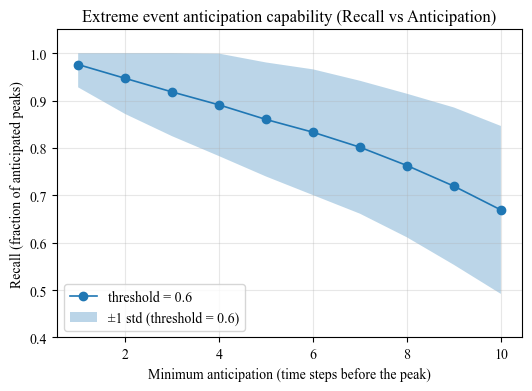

In [16]:
test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=config["p_model"]["p_value"],
    num_series=config["data"]["num_series_test"],
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

indices = np.linspace(0, len(test_series) - 1, 500, dtype=int)

for count, i in enumerate(indices):
    df = test_series[i]

    print(
        f"\n Synthetic series {count + 1}/{len(indices)} "
        f"(index {i})"
    )

    metrics, ks, recalls = evaluate_and_plot_streaming(
        model,
        df,
        device,
        lookahead=config["data"]["lookahead"],
        plot=False,
        title="P-model time series with extreme event labels and LSTM prediction"
    )

    print(metrics)

    all_metrics.append(metrics)
    all_recalls.append(recalls)


# ---------- Aggregate recalls ----------
all_recalls = np.array(all_recalls)  

mean_recall = np.nanmean(all_recalls, axis=0)
std_recall = np.nanstd(all_recalls, axis=0)

# Clip to valid recall range
lower = np.clip(mean_recall - std_recall, 0, 1)
upper = np.clip(mean_recall + std_recall, 0, 1)

# ---------- Recall vs Anticipation Plot ----------
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    mean_recall,
    marker="o",
    markersize=6,
    linewidth=1.2,
    label="threshold = 0.6"
)

plt.fill_between(
    ks,
    lower,
    upper,
    alpha=0.3,
    label="±1 std (threshold = 0.6)"
)

plt.xlabel("Minimum anticipation (time steps before the peak)")
plt.ylabel("Recall (fraction of anticipated peaks)")
plt.title("Extreme event anticipation capability (Recall vs Anticipation)")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0.4, 1.05)

plt.show()



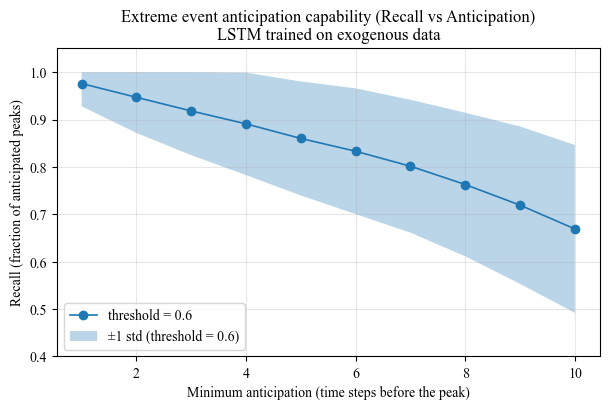

In [17]:
plt.figure(figsize=(7, 4))

plt.plot(
    ks,
    mean_recall,
    marker="o",
    markersize=6,
    linewidth=1.2,
    label="threshold = 0.6"
)

plt.fill_between(
    ks,
    lower,
    upper,
    alpha=0.3,
    label="±1 std (threshold = 0.6)"
)

plt.xlabel("Minimum anticipation (time steps before the peak)")
plt.ylabel("Recall (fraction of anticipated peaks)")
plt.title(
    "Extreme event anticipation capability (Recall vs Anticipation)\n"
    "LSTM trained on exogenous data"
)
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0.4, 1.05)

plt.show()

In [18]:

test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=[0.18, 0.42],
    num_series=config["data"]["num_series_test"],
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

indices = np.linspace(0, len(test_series) - 1, 500, dtype=int)

for count, i in enumerate(indices):
    df = test_series[i]

    print(
        f"\n Synthetic series {count + 1}/{len(indices)} "
        f"(index {i})"
    )

    metrics, ks, recalls = evaluate_and_plot_streaming(
        model,
        df,
        device,
        lookahead=config["data"]["lookahead"],
        plot=False,
        title="P-model time series with extreme event labels and LSTM prediction"
    )

    print(metrics)

    all_metrics.append(metrics)
    all_recalls.append(recalls)


# ---------- Aggregate recalls ----------
all_recalls = np.array(all_recalls)  

mean_recall = np.nanmean(all_recalls, axis=0)
std_recall = np.nanstd(all_recalls, axis=0)

# Clip to valid recall range
lower = np.clip(mean_recall - std_recall, 0, 1)
upper = np.clip(mean_recall + std_recall, 0, 1)



[0.18, 0.42]

 Synthetic series 1/500 (index 0)
{'AUC-PR': 0.7889979806185733, 'Precision': 0.5963302752293578, 'Recall': 0.8227848101265823, 'F1': 0.6914893617021277, 'P-value': np.float64(0.18)}

 Synthetic series 2/500 (index 3)
{'AUC-PR': 0.6184040180513102, 'Precision': 0.3984375, 'Recall': 0.68, 'F1': 0.5024630541871922, 'P-value': np.float64(0.18)}

 Synthetic series 3/500 (index 6)
{'AUC-PR': 0.6608610780035719, 'Precision': 0.46956521739130436, 'Recall': 0.6835443037974683, 'F1': 0.5567010309278351, 'P-value': np.float64(0.18)}

 Synthetic series 4/500 (index 9)
{'AUC-PR': 0.5474084149618331, 'Precision': 0.4485981308411215, 'Recall': 0.6153846153846154, 'F1': 0.518918918918919, 'P-value': np.float64(0.18)}

 Synthetic series 5/500 (index 12)
{'AUC-PR': 0.8143864188813964, 'Precision': 0.5182481751824818, 'Recall': 0.8658536585365854, 'F1': 0.6484018264840182, 'P-value': np.float64(0.18)}

 Synthetic series 6/500 (index 15)
{'AUC-PR': 0.7031874074379266, 'Precision': 0.5284552

In [19]:
all_metrics = pd.DataFrame(all_metrics)
all_metrics['P-value'] = all_metrics['P-value'].astype(float).round(2)

table = (
    all_metrics
    .groupby('P-value', as_index=False)
    .mean()
)

def highlight_best_worst(s):
    is_max = s == s.max()
    is_min = s == s.min()
    
    styles = []
    for max_v, min_v in zip(is_max, is_min):
        if max_v:
            styles.append('background-color: #b7f7c1; font-weight: bold')  # best (green)
        elif min_v:
            styles.append('background-color: #f7b7b7; font-weight: bold')  # worst (red)
        else:
            styles.append('')
    
    return styles

styled_table = (
    table
    .style
    .apply(highlight_best_worst, axis=0)  
    .format("{:.3f}")
)

styled_table

,P-value,AUC-PR,Precision,Recall,F1
0,0.180,0.668,0.477,0.743,0.580
1,0.190,0.691,0.537,0.717,0.596
2,0.200,0.677,0.505,0.702,0.580
3,0.210,0.678,0.515,0.704,0.583
4,0.220,0.727,0.521,0.758,0.608
5,0.230,0.678,0.494,0.728,0.580
6,0.240,0.696,0.507,0.733,0.591
7,0.250,0.705,0.527,0.728,0.600
8,0.260,0.717,0.545,0.729,0.614
9,0.270,0.751,0.542,0.783,0.635


In [20]:
# Split by P-value ranges
exogenous = all_metrics[(all_metrics['P-value'] >= 0.18) & (all_metrics['P-value'] <= 0.28)]
transition = all_metrics[(all_metrics['P-value'] > 0.28) & (all_metrics['P-value'] < 0.32)]
endogenous = all_metrics[(all_metrics['P-value'] >= 0.32) & (all_metrics['P-value'] <= 0.42)]
mixed = all_metrics  

# Compute means
table = pd.DataFrame({
    'Exogenous': exogenous.mean(),
    'Transition': transition.mean(),
    'Endogenous': endogenous.mean(),
    'Mixed': mixed.mean()
}).T

# Drop P-value column (not meaningful to average)
table = table.drop(columns=['P-value'])

# Style table
styled_table = (
    table
    .style
    .apply(highlight_best_worst, axis=0)
    .format("{:.3f}")
)

table.to_csv("../paper/metrics_by_regime_exogenous.csv", float_format="%.3f")

styled_table


,AUC-PR,Precision,Recall,F1
Exogenous,0.702,0.518,0.736,0.598
Transition,0.751,0.554,0.770,0.634
Endogenous,0.549,0.371,0.782,0.492
Mixed,0.641,0.458,0.760,0.556


[0.25, 0.25]

 Synthetic series 1/3 


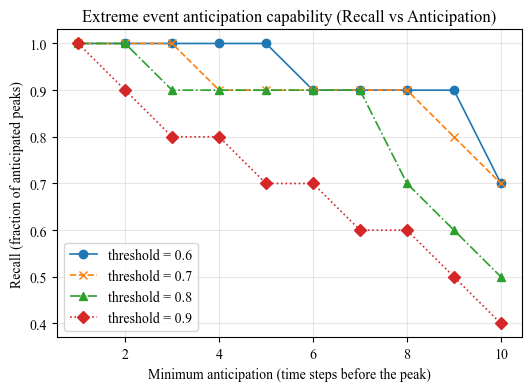

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_88493/890748804.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


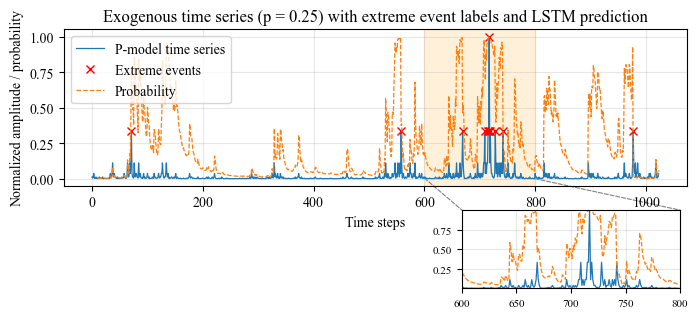

{'AUC-PR': 0.7216154848437664, 'Precision': 0.4878048780487805, 'Recall': 0.759493670886076, 'F1': 0.594059405940594, 'P-value': np.float64(0.25)}

 Synthetic series 2/3 


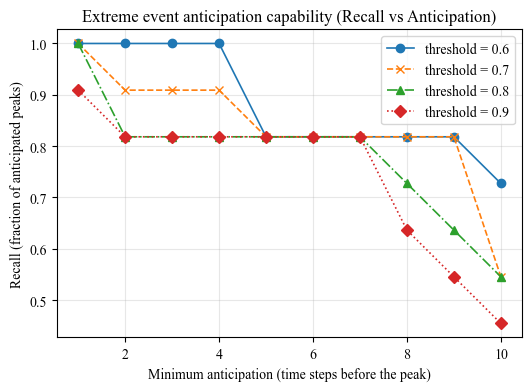

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_88493/890748804.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


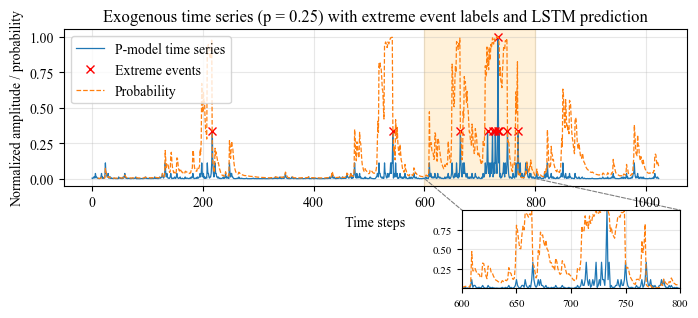

{'AUC-PR': 0.8161043686157854, 'Precision': 0.7021276595744681, 'Recall': 0.8148148148148148, 'F1': 0.7542857142857143, 'P-value': np.float64(0.25)}

 Synthetic series 3/3 


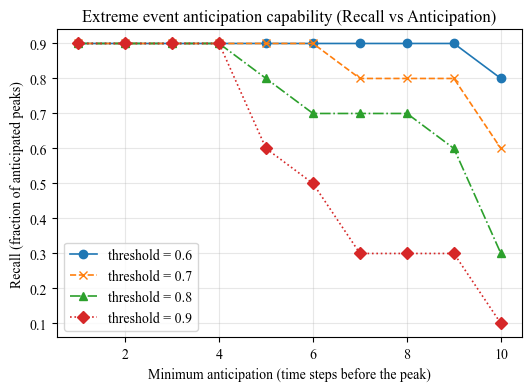

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_88493/890748804.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


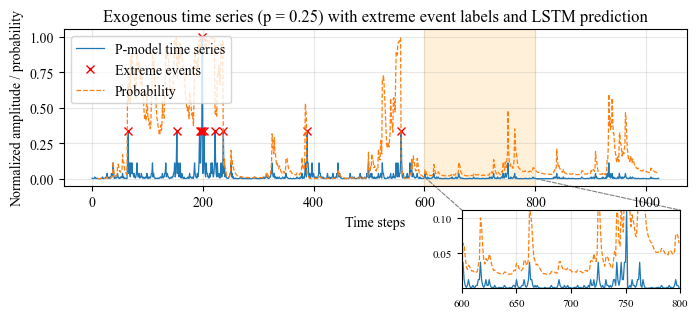

{'AUC-PR': 0.6180543490686246, 'Precision': 0.4351145038167939, 'Recall': 0.7307692307692307, 'F1': 0.5454545454545454, 'P-value': np.float64(0.25)}


In [21]:
np.random.seed(26)

test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=[0.25, 0.25],
    num_series=3,
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

for count, df in enumerate(test_series):

    print(
        f"\n Synthetic series {count + 1}/{len(test_series)} "
    )

    metrics, ks, recalls = evaluate_and_plot_streaming(
        model,
        df,
        device,
        lookahead=config["data"]["lookahead"],
        plot=True,
        box_cut=(600, 800),
        title="Exogenous time series (p = 0.25) with extreme event labels and LSTM prediction"
    )

    print(metrics)

    all_metrics.append(metrics)
    all_recalls.append(recalls)



[0.3, 0.3]

 Synthetic series 1/3 


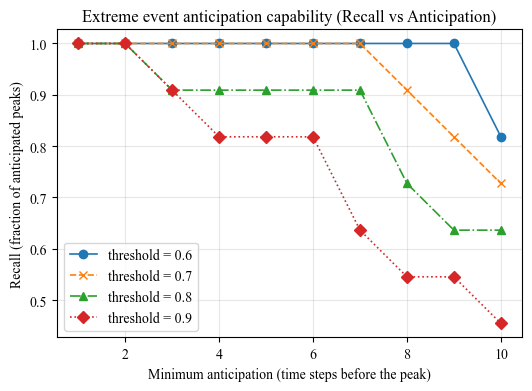

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_88493/890748804.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


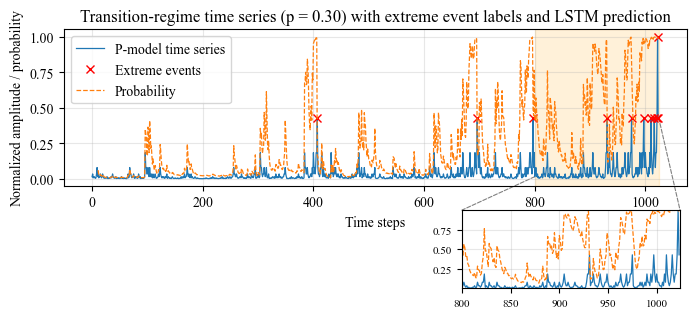

{'AUC-PR': 0.8565198072344097, 'Precision': 0.5492957746478874, 'Recall': 0.9397590361445783, 'F1': 0.6933333333333334, 'P-value': np.float64(0.3)}

 Synthetic series 2/3 


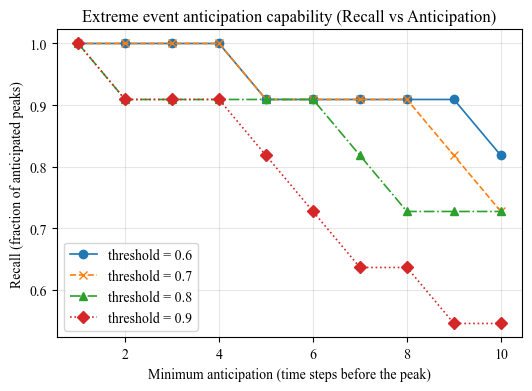

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_88493/890748804.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


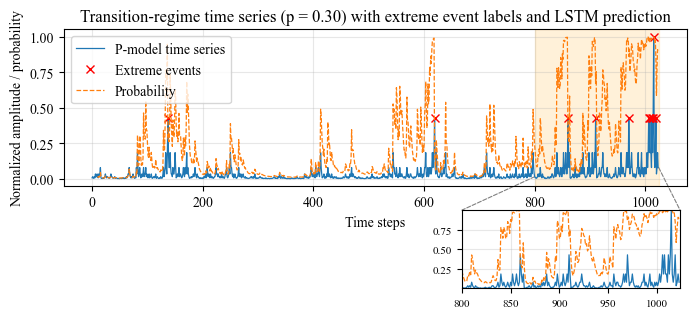

{'AUC-PR': 0.8057844589003235, 'Precision': 0.5238095238095238, 'Recall': 0.9041095890410958, 'F1': 0.6633165829145728, 'P-value': np.float64(0.3)}

 Synthetic series 3/3 


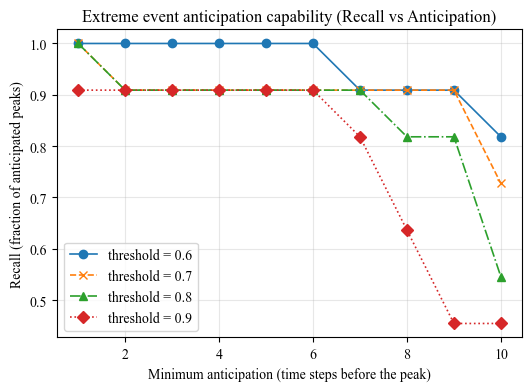

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_88493/890748804.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


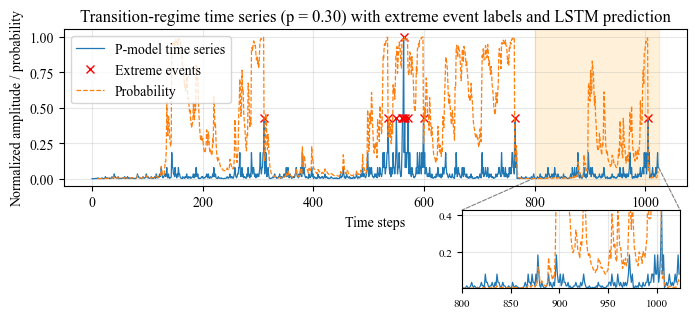

{'AUC-PR': 0.6997095903174759, 'Precision': 0.3231441048034934, 'Recall': 0.925, 'F1': 0.47896440129449835, 'P-value': np.float64(0.3)}


In [22]:
np.random.seed(11)

test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=[0.30, 0.30],
    num_series=3,
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

for count, df in enumerate(test_series):

    print(
        f"\n Synthetic series {count + 1}/{len(test_series)} "
    )

    metrics, ks, recalls = evaluate_and_plot_streaming(
        model,
        df,
        device,
        lookahead=config["data"]["lookahead"],
        plot=True,
        box_cut=(800, 1024),
        title="Transition-regime time series (p = 0.30) with extreme event labels and LSTM prediction"
    )

    print(metrics)

    all_metrics.append(metrics)
    all_recalls.append(recalls)



In [23]:
#Evaluation on real Tokamak data
# file_path = "./data/jorek/heat_flux_iter.csv"
# file_path = "./data/jorek/heat_flux_iter_resampled.csv"
# file_path = "./data/geomagnetic/ae_index_normalizado.csv"
file_path = "./data/sdo/sdo_time_series.csv"
# file_path = "./data/sdo/sdo_resampled.csv"

df_real = load_and_prepare_csv(
    file_path,
    peak_percentile=config["data"]["peak_percentile"],
)

# Use percentile of lower values as reference and subtract it
percentile_val = np.percentile(df_real['normalized_amplitude'], 10)
df_real['normalized_amplitude'] = df_real['normalized_amplitude'] - percentile_val
max_val = df_real['normalized_amplitude'].max()
df_real['normalized_amplitude'] = df_real['normalized_amplitude'] / max_val


evaluate_and_plot_streaming(
    model,
    df_real,
    device,
    lookahead=config["data"]["lookahead"],
    title="Jorek time series with extreme event labels and LSTM prediction"
)


Loading file: sdo_time_series.csv


TypeError: cannot unpack non-iterable NoneType object